**Upload Dataset**

In [ ]:
# import modules
!pip install -q selfies
from google.colab import drive
import numpy as np
import csv
import pandas as pd
import selfies as sf
from matplotlib.ticker import PercentFormatter

In [ ]:
# mount the drive
drive.mount('/content/drive')
dir = "/content/drive/My Drive/Colab_Notebooks/IL_Manuscript/Model_1/"

# import the SELFIES alphabet
SELFIES_alphabet = np.load(dir + 'data/SELFIES_alphabet.npy',allow_pickle='TRUE').item()

# import the SELFIES dataset
with open(dir + 'data/298_299K_dataset.csv', newline='') as file:
    dataset = pd.read_csv(file)

Mounted at /content/drive


**Molecular Descriptor**

*One-Hot Encoding of Molecular Physical Structure*

In [ ]:
# one-hot encoding
def OneHot(selfies):
    label, one_hot = sf.selfies_to_encoding(
            selfies=selfies,
            vocab_stoi=SELFIES_alphabet,
            pad_to_len=76,
            enc_type = "both")
    return one_hot

for i in range (0,len(dataset.index)):
  dataset['ion1'][i] = OneHot(dataset.iloc[i][1]) + OneHot(dataset.iloc[i][2])

del dataset['ion2']
dataset.rename(columns = {'ion1':'ions'}, inplace = True)

<ipython-input-3-f9e429160452>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['ion1'][i] = OneHot(dataset.iloc[i][1]) + OneHot(dataset.iloc[i][2])


*Proprocess Density*

In [ ]:
dataset['density'] = dataset['density']/1000

**298-299K DNN Model Setup**

In [ ]:
# upload transfer_learning.py
from google.colab import files
files.upload()

Saving transfer_learning.py to transfer_learning.py


{'transfer_learning.py': b'from __future__ import print_function, division\n\nimport torch\nimport torch.nn as nn \nimport torch.optim as optim\nfrom torch.optim import lr_scheduler\nfrom torch.autograd import Variable \n\nimport numpy as np \nimport matplotlib.pyplot as plt \nimport time \nimport os \n\nclass NeuralNet(nn.Module):\n\tdef __init__(self, input_size, hidden_size_1, hidden_size_2, output_size):\n\t\tsuper(NeuralNet, self).__init__()\n\t\tself.fc1 = nn.Linear(input_size, hidden_size_1)\n\t\tself.fc2 = nn.Linear(hidden_size_1, hidden_size_2)\n\t\tself.fc3 = nn.Linear(hidden_size_2, output_size)\n\t\tself.relu = nn.ReLU()\n\n\tdef forward(self, x):\n\t\tout = self.fc1(x)\n\t\tout = self.relu(out)\n\t\tout = self.fc2(out)\n\t\tout = self.relu(out)\n\t\tout = self.fc3(out)\n\t\treturn out \n'}

In [ ]:
# transfer_learning.py
from transfer_learning import NeuralNet

# principal component analysis
from sklearn.decomposition import PCA

# DNN training
import torch
import torch.nn as nn
import torch.optim as optim
import os, sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# permutation feature importance
!pip install -q eli5
from sklearn.neural_network import MLPRegressor
import eli5
from eli5.sklearn import PermutationImportance

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 12.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# input X and output y
X = []
y = []
for i in range(0,len(dataset.index)):
    X.append(dataset['ions'][i])
    y.append(dataset['density'][i])
for i in range(0,len(X)):
  X[i] = np.array(X[i]).reshape(7904,).astype(np.float32)
  y[i] = y[i].astype(np.float32)
X = np.array(X)
y = np.array(y)

**Model A: 50 Principle Components**

*DNN Model*

100%|██████████| 2000/2000 [00:03<00:00, 575.31it/s]


The MAPE on test set is 6.440437585115433%


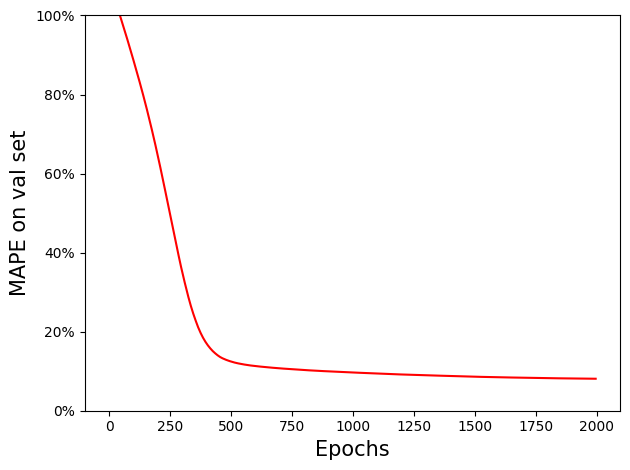

In [ ]:
# PCA
PC = []
for i in range (1, 51):
  PC.append('PC'+str(i))
pca = PCA(n_components = 50)
pca.fit(X)
data_pca = pca.transform(X)
df_PCA = pd.DataFrame(data_pca,columns=PC)
X_PCA = df_PCA.to_numpy()

# DNN training
input_size = 50
hidden_size_1 = 30
hidden_size_2 = 15
output_size = 1
learning_rate = 0.0002

model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

X_train, X_test, y_train, y_test = train_test_split(X_PCA, y, test_size=0.1, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=1)

scores_epochs = list()
num_epochs = 2000
train_losses = []

for epoch in tqdm(range(num_epochs)):
    inputs = torch.from_numpy(X_train).to(device)
    labels = torch.from_numpy(y_train).to(device)

    outputs = model(inputs).view(-1,)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        inputs_val = torch.from_numpy(X_val).to(device)
        labels_val = torch.from_numpy(y_val).to(device)

        outputs_val = model(inputs_val).view(-1,)
        score = mean_absolute_percentage_error(labels_val.data.cpu().numpy(), outputs_val.data.cpu().numpy())
        scores_epochs.append(score)

plt.gca().yaxis.set_major_formatter(PercentFormatter (1, decimals=0))
plt.plot(np.arange(0, num_epochs, 5), scores_epochs, color='red')
plt.ylim(0,1)
plt.xlabel('Epochs', size=15)
plt.ylabel('MAPE on val set', size=15)

X_test_tensor = torch.from_numpy(X_test).to(device)
y_test_tensor = torch.from_numpy(y_test).to(device)

output_test = model(X_test_tensor).view(-1,).cpu().data.numpy()

mape_test = mean_absolute_percentage_error(y_test_tensor.cpu().data.numpy(), output_test) * 100

print('The MAPE on test set is {}%'.format(mape_test))

plt.tight_layout()
plt.savefig(dir + 'figures/298_299K/A_training_curve.png', dpi=600)
torch.save(model.state_dict(), dir + 'model/298_299K/A_298_299K_model.ckpt')

*Learning Curve*

In [ ]:
# learning curve
input_size = 50
hidden_size_1 = 30
hidden_size_2 = 15
output_size = 1
learning_rate = 0.0002

model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

x = 9
error_train = np.zeros(int(len(X_train)/x))
error_val = np.zeros(int(len(X_train)/x))

for i,N in enumerate(range(x, len(X_train)+1, x)):
  X_train_LC = X_train[:N]
  y_train_LC = y_train[:N]
  X_val_LC = X_val
  y_val_LC = y_val
  
  model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
  criterion = nn.MSELoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  val_scores_epochs = list()
  train_scores_epochs = list()
  num_epochs = 2000

  for epoch in tqdm(range(num_epochs)):
      inputs = torch.from_numpy(X_train_LC).to(device)
      labels = torch.from_numpy(y_train_LC).to(device)

      outputs = model(inputs).view(-1,)
      loss = criterion(outputs, labels)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      train_scores_epochs.append(loss)

      inputs_val = torch.from_numpy(X_val_LC).to(device)
      labels_val = torch.from_numpy(y_val_LC).to(device)

      outputs_val = model(inputs_val).view(-1,)
      score = mean_squared_error(labels_val.data.cpu().numpy(), outputs_val.data.cpu().numpy())
      val_scores_epochs.append(score)

  error_train[i] = train_scores_epochs[-1]
  error_val[i] = val_scores_epochs[-1] 

df_error_train = pd.DataFrame(error_train)
df_error_val = pd.DataFrame(error_val)

df_error_train.to_csv(dir + 'figures/data/learning_curve/A_298_299K_train.csv') 
df_error_val.to_csv(dir + 'figures/data/learning_curve/A_298_299K_val.csv') 

100%|██████████| 2000/2000 [00:06<00:00, 287.62it/s]


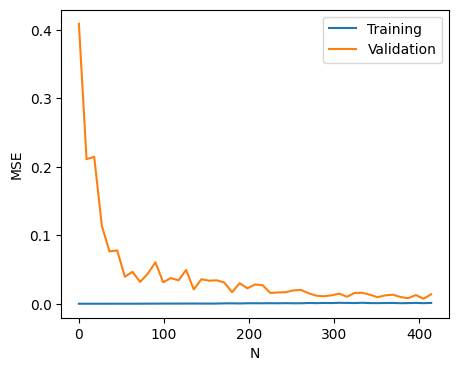

In [ ]:
x_axis = list()
for i,N in enumerate(range(x, len(X_train)+1, x)):
  x_axis.append(i*x)

with open(dir + 'figures/data/learning_curve/A_298_299K_train.csv', newline='') as file1:
    csv_error_train = pd.read_csv(file1)
with open(dir + 'figures/data/learning_curve/A_298_299K_val.csv', newline='') as file2:
    csv_error_val = pd.read_csv(file2)

csv_error_train.columns =['index', 'loss']
csv_error_val.columns =['index', 'loss']

lst_error_train = csv_error_train['loss'].tolist()
lst_error_val = csv_error_val['loss'].tolist()
plt.figure(figsize=(5,4))
plt.plot(x_axis, lst_error_train, label='Training')
plt.plot(x_axis, lst_error_val, label='Validation')
plt.legend()
plt.ylabel('MSE')
plt.xlabel('N')
plt.savefig(dir + 'figures/298_299K/A_learning_curve.png', format='png', dpi=600)

*Feature Importance Analysis*

In [ ]:
regr = MLPRegressor(hidden_layer_sizes=(30, 15), solver='adam', activation = 'relu', random_state=1, max_iter=2000, learning_rate='constant',learning_rate_init=0.0002).fit(X_train, y_train)
perm = PermutationImportance(regr.fit(X_train,y_train), random_state=1).fit(X_test,y_test)
eli5.formatters.as_dataframe.explain_weights_df(perm, feature_names = df_PCA.columns.tolist(), top=50).to_csv(dir + 'figures/data/feature_importance/A_298_299K.csv')

**Model B (Part 1): Complete 7904 Features**


*DNN Model*

100%|██████████| 60/60 [00:00<00:00, 197.76it/s]


The MAPE on test set is 4.588298499584198%


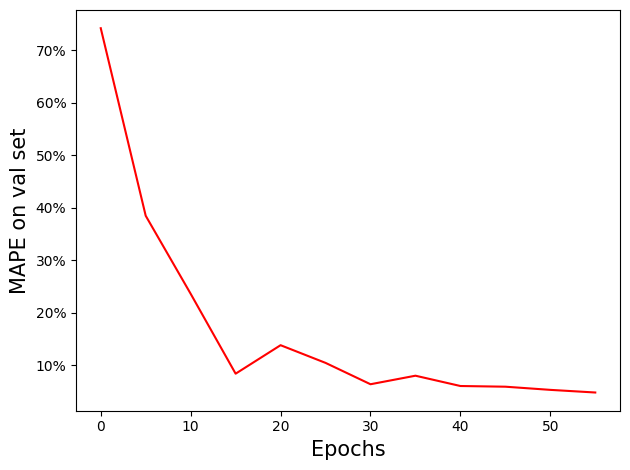

In [ ]:
# DNN training
input_size = 7904
hidden_size_1 = 1000
hidden_size_2 = 300
output_size = 1
learning_rate = 0.0005

model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=1)

scores_epochs = list()
num_epochs = 60
train_losses = []

for epoch in tqdm(range(num_epochs)):
    inputs = torch.from_numpy(X_train).to(device)
    labels = torch.from_numpy(y_train).to(device)

    outputs = model(inputs).view(-1,)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        inputs_val = torch.from_numpy(X_val).to(device)
        labels_val = torch.from_numpy(y_val).to(device)

        outputs_val = model(inputs_val).view(-1,)
        score = mean_absolute_percentage_error(labels_val.data.cpu().numpy(), outputs_val.data.cpu().numpy())
        scores_epochs.append(score)

plt.gca().yaxis.set_major_formatter(PercentFormatter (1, decimals=0))
plt.plot(np.arange(0, num_epochs, 5), scores_epochs, color='red')
plt.xlabel('Epochs', size=15)
plt.ylabel('MAPE on val set', size=15)

X_test_tensor = torch.from_numpy(X_test).to(device)
y_test_tensor = torch.from_numpy(y_test).to(device)

output_test = model(X_test_tensor).view(-1,).cpu().data.numpy()

mape_test = mean_absolute_percentage_error(y_test_tensor.cpu().data.numpy(), output_test) * 100

print('The MAPE on test set is {}%'.format(mape_test))

plt.tight_layout()
plt.savefig(dir + 'figures/298_299K/B_part1_training_curve.png', dpi=600)

*Learning Curve*

In [ ]:
# learning curve
input_size = 7904
hidden_size_1 = 1000
hidden_size_2 = 300
output_size = 1
learning_rate = 0.0005

model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

x = 9
error_train = np.zeros(int(len(X_train)/x))
error_val = np.zeros(int(len(X_train)/x))

for i,N in enumerate(range(x, len(X_train)+1, x)):
  X_train_LC = X_train[:N]
  y_train_LC = y_train[:N]
  X_val_LC = X_val
  y_val_LC = y_val
  
  model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
  criterion = nn.MSELoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  val_scores_epochs = list()
  train_scores_epochs = list()
  num_epochs = 60

  for epoch in tqdm(range(num_epochs)):
      inputs = torch.from_numpy(X_train_LC).to(device)
      labels = torch.from_numpy(y_train_LC).to(device)

      outputs = model(inputs).view(-1,)
      loss = criterion(outputs, labels)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      train_scores_epochs.append(loss)

      inputs_val = torch.from_numpy(X_val_LC).to(device)
      labels_val = torch.from_numpy(y_val_LC).to(device)

      outputs_val = model(inputs_val).view(-1,)
      score = mean_squared_error(labels_val.data.cpu().numpy(), outputs_val.data.cpu().numpy())
      val_scores_epochs.append(score)

  error_train[i] = train_scores_epochs[-1]
  error_val[i] = val_scores_epochs[-1] 

df_error_train = pd.DataFrame(error_train)
df_error_val = pd.DataFrame(error_val)

df_error_train.to_csv(dir + 'figures/data/learning_curve/B_part1_298_299K_train.csv') 
df_error_val.to_csv(dir + 'figures/data/learning_curve/B_part1_298_299K_val.csv')

100%|██████████| 60/60 [00:00<00:00, 164.13it/s]


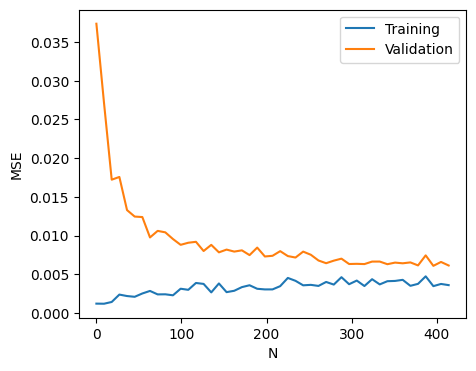

In [ ]:
x_axis = list()
for i,N in enumerate(range(x, len(X_train)+1, x)):
  x_axis.append(i*x)

with open(dir + 'figures/data/learning_curve/B_part1_298_299K_train.csv', newline='') as file1:
    csv_error_train = pd.read_csv(file1)
with open(dir + 'figures/data/learning_curve/B_part1_298_299K_val.csv', newline='') as file2:
    csv_error_val = pd.read_csv(file2)

csv_error_train.columns =['index', 'loss']
csv_error_val.columns =['index', 'loss']

lst_error_train = csv_error_train['loss'].tolist()
lst_error_val = csv_error_val['loss'].tolist()
plt.figure(figsize=(5,4))
plt.plot(x_axis, lst_error_train, label='Training')
plt.plot(x_axis, lst_error_val, label='Validation')
plt.legend()
plt.ylabel('MSE')
plt.xlabel('N')
plt.savefig(dir + 'figures/298_299K/B_part1_learning_curve.png', format='png', dpi=600)

*Permutation Feature Importance*

In [ ]:
regr = MLPRegressor(hidden_layer_sizes=(1000, 300), solver='adam', activation = 'relu', random_state=1, max_iter=60, learning_rate='constant',learning_rate_init=0.0005).fit(X_train, y_train)
perm = PermutationImportance(regr.fit(X_train,y_train), random_state=1).fit(X_test,y_test)

In [ ]:
eli5.formatters.as_dataframe.explain_weights_df(perm, top=500).to_csv(dir + 'figures/data/feature_importance/B_part1_298_299K.csv')
df = eli5.format_as_dataframe(eli5.explain_weights(perm, top=500))
df = df.drop(df[(df['weight'] == 0) & (df['std'] == 0)].index)
df['feature'] = df['feature'].str.replace('x', '')
for i in range(0,len(df['feature'])):
  df['feature'][i] = int(df['feature'][i])
nonzero_feature_index = df['feature'].to_numpy()
print(nonzero_feature_index)

[4835 861 29 806 1039 4480 767 4810 1222 681 18 4460 4654 4862 3990 4009
 1170 384 4633 234 1112 4620 4285 4220 229 508 724 78 5063 516 378 5070
 586 57 100 5798 170 601 92 4117 4141 4740 4562 27 26 5018 5642 4428 794
 450 4170 4109 4516 592 4544 4477 1091 4939 488 4891 4731 4453 4302 4238
 4290 4270 653 913 4328 4828 1381 846 546 4336 1485 984 125 1507 5590 3992
 4568 159 403 5538 1559 4532 4324 213 5694 4329 889 317 727 222 4024 4284
 34 109 4193 4250 200 1589 4856 1586 1268 4966 757 4134 280 4737 598 1106
 148 4914 5850 1225 1262 4841 4724 1403 454 1351 4839 883 4783 935 632 246
 1663 4168 338 33 5954 4212 1149 4596 456 4201 421 1693 4197 473 1715 658
 4887 702 5902 525 612 4679 4263 390 4425 993 1118 1002 356 5064 1066 162
 4752 4004 4474 48 4505 809 715 644 1143 5875 5746 1299 4948 663 72 124
 5272 408 1641 103 559 1287 4636 4044 4668 326 38 4772 1326 4409 5486 4550
 623 196 5563 1534 4493 1433 265 256 1097 351 754 4082 5459 650 1455 149
 308 831 369 4057 161 4492 5304 73 207 680 

<ipython-input-65-9d9e3a900adb>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['feature'][i] = int(df['feature'][i])


**Model B (Part 2): 285 SELFIES-Collapsed Features**

*DNN Model*

In [ ]:
# filter out 285 features with nonzero-importance
X_filtered =[[]for i in range(len(dataset.index))]
for i in range (0,len(dataset.index)):
  for j in nonzero_feature_index:
    X_filtered[i].append(X[i][j])
X_filtered = np.array(X_filtered)
column = list()
for i in nonzero_feature_index:
  column.append('#' + str(i))
df_X_filtered = pd.DataFrame(X_filtered,columns= column)

100%|██████████| 600/600 [00:01<00:00, 564.87it/s]


The MAPE on test set is 4.3801214545965195%


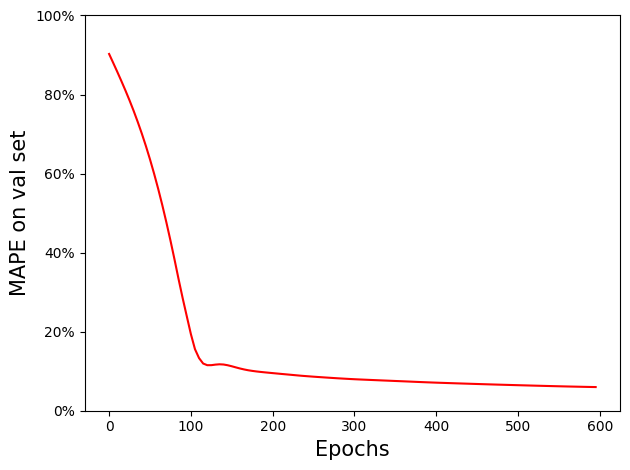

In [ ]:
# DNN training
input_size = 285
hidden_size_1 = 190
hidden_size_2 = 95
output_size = 1
learning_rate = 0.00005

model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.1, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=1)

scores_epochs = list()
num_epochs = 600
train_losses = []

for epoch in tqdm(range(num_epochs)):
    inputs = torch.from_numpy(X_train).to(device)
    labels = torch.from_numpy(y_train).to(device)

    outputs = model(inputs).view(-1,)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        inputs_val = torch.from_numpy(X_val).to(device)
        labels_val = torch.from_numpy(y_val).to(device)

        outputs_val = model(inputs_val).view(-1,)
        score = mean_absolute_percentage_error(labels_val.data.cpu().numpy(), outputs_val.data.cpu().numpy())
        scores_epochs.append(score)

plt.gca().yaxis.set_major_formatter(PercentFormatter (1, decimals=0))
plt.plot(np.arange(0, num_epochs, 5), scores_epochs, color='red')
plt.ylim(0,1)
plt.xlabel('Epochs', size=15)
plt.ylabel('MAPE on val set', size=15)

X_test_tensor = torch.from_numpy(X_test).to(device)
y_test_tensor = torch.from_numpy(y_test).to(device)

output_test = model(X_test_tensor).view(-1,).cpu().data.numpy()

mape_test = mean_absolute_percentage_error(y_test_tensor.cpu().data.numpy(), output_test) * 100

print('The MAPE on test set is {}%'.format(mape_test))

plt.tight_layout()
plt.savefig(dir + 'figures/298_299K/B_part2_training_curve.png', dpi=600)
torch.save(model.state_dict(), dir + 'model/298_299K/B_298_299K_model.ckpt')

*Learning Curve*

In [ ]:
# learning curve
input_size = 285
hidden_size_1 = 190
hidden_size_2 = 95
output_size = 1
learning_rate = 0.00005

model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

x = 9
error_train = np.zeros(int(len(X_train)/x))
error_val = np.zeros(int(len(X_train)/x))

for i,N in enumerate(range(x, len(X_train)+1, x)):
  X_train_LC = X_train[:N]
  y_train_LC = y_train[:N]
  X_val_LC = X_val
  y_val_LC = y_val
  
  model = NeuralNet(input_size, hidden_size_1, hidden_size_2, output_size).to(device)
  criterion = nn.MSELoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  val_scores_epochs = list()
  train_scores_epochs = list()
  num_epochs = 600

  for epoch in tqdm(range(num_epochs)):
      inputs = torch.from_numpy(X_train_LC).to(device)
      labels = torch.from_numpy(y_train_LC).to(device)

      outputs = model(inputs).view(-1,)
      loss = criterion(outputs, labels)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      train_scores_epochs.append(loss)

      inputs_val = torch.from_numpy(X_val_LC).to(device)
      labels_val = torch.from_numpy(y_val_LC).to(device)

      outputs_val = model(inputs_val).view(-1,)
      score = mean_squared_error(labels_val.data.cpu().numpy(), outputs_val.data.cpu().numpy())
      val_scores_epochs.append(score)

  error_train[i] = train_scores_epochs[-1]
  error_val[i] = val_scores_epochs[-1] 

df_error_train = pd.DataFrame(error_train)
df_error_val = pd.DataFrame(error_val)

df_error_train.to_csv(dir + 'figures/data/learning_curve/B_part2_298_299K_train.csv') 
df_error_val.to_csv(dir + 'figures/data/learning_curve/B_part2_298_299K_val.csv')

100%|██████████| 600/600 [00:01<00:00, 428.60it/s]


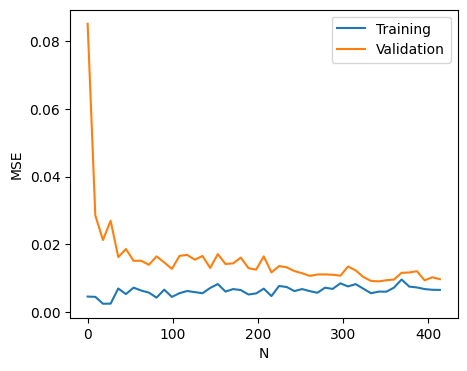

In [ ]:
x_axis = list()
for i,N in enumerate(range(x, len(X_train)+1, x)):
  x_axis.append(i*x)

with open(dir + 'figures/data/learning_curve/B_part2_298_299K_train.csv', newline='') as file1:
    csv_error_train = pd.read_csv(file1)
with open(dir + 'figures/data/learning_curve/B_part2_298_299K_val.csv', newline='') as file2:
    csv_error_val = pd.read_csv(file2)

csv_error_train.columns =['index', 'loss']
csv_error_val.columns =['index', 'loss']

lst_error_train = csv_error_train['loss'].tolist()
lst_error_val = csv_error_val['loss'].tolist()
plt.figure(figsize=(5,4))
plt.plot(x_axis, lst_error_train, label='Training')
plt.plot(x_axis, lst_error_val, label='Validation')
plt.legend()
plt.ylabel('MSE')
plt.xlabel('N')
plt.savefig(dir + 'figures/298_299K/B_part2_learning_curve.png', format='png', dpi=600)

*Feature Importance Analysis*

In [ ]:
regr = MLPRegressor(hidden_layer_sizes=(190, 95), solver='adam', activation = 'relu', random_state=1, max_iter=600, learning_rate='constant',learning_rate_init=0.00005).fit(X_train, y_train)
perm = PermutationImportance(regr.fit(X_train,y_train), random_state=1).fit(X_test,y_test)
eli5.formatters.as_dataframe.explain_weights_df(perm, feature_names = df_X_filtered.columns.tolist(), top=285).to_csv(dir + 'figures/data/feature_importance/B_part2_298_299K.csv')